# 04 · Ethics — who gets acted on, and where it ports

> Synthetic data; read magnitudes as a method demonstration.

Thin wrapper over `src/ethics`. Regenerate with `make ethics && make transport`.

In [1]:
import os, sys
from pathlib import Path

# Make the repo root the working dir and importable, whether this notebook is
# launched from notebooks/ or from the repo root.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image
pd.set_option("display.width", 120)
print("repo root:", ROOT)

repo root: /Users/jimmy/Documents/hr-attrition-analytics


## Fairness audit — who gets flagged (top-20%)

DP ratio < 0.80 trips the four-fifths rule; EO diff = error-rate gap vs actual attrition. Risk-targeting amplifies disparity; uplift-targeting partly corrects it but isn't free.

,policy,attribute,dp_difference,dp_ratio,eo_difference
0,risk,Gender,0.024,0.890,0.110
1,uplift,Gender,0.070,0.714,0.099
2,risk,MaritalStatus,0.317,0.208,0.500
3,uplift,MaritalStatus,0.110,0.593,0.375
4,risk,AgeBand,0.250,0.267,0.592
5,uplift,AgeBand,0.151,0.475,0.129


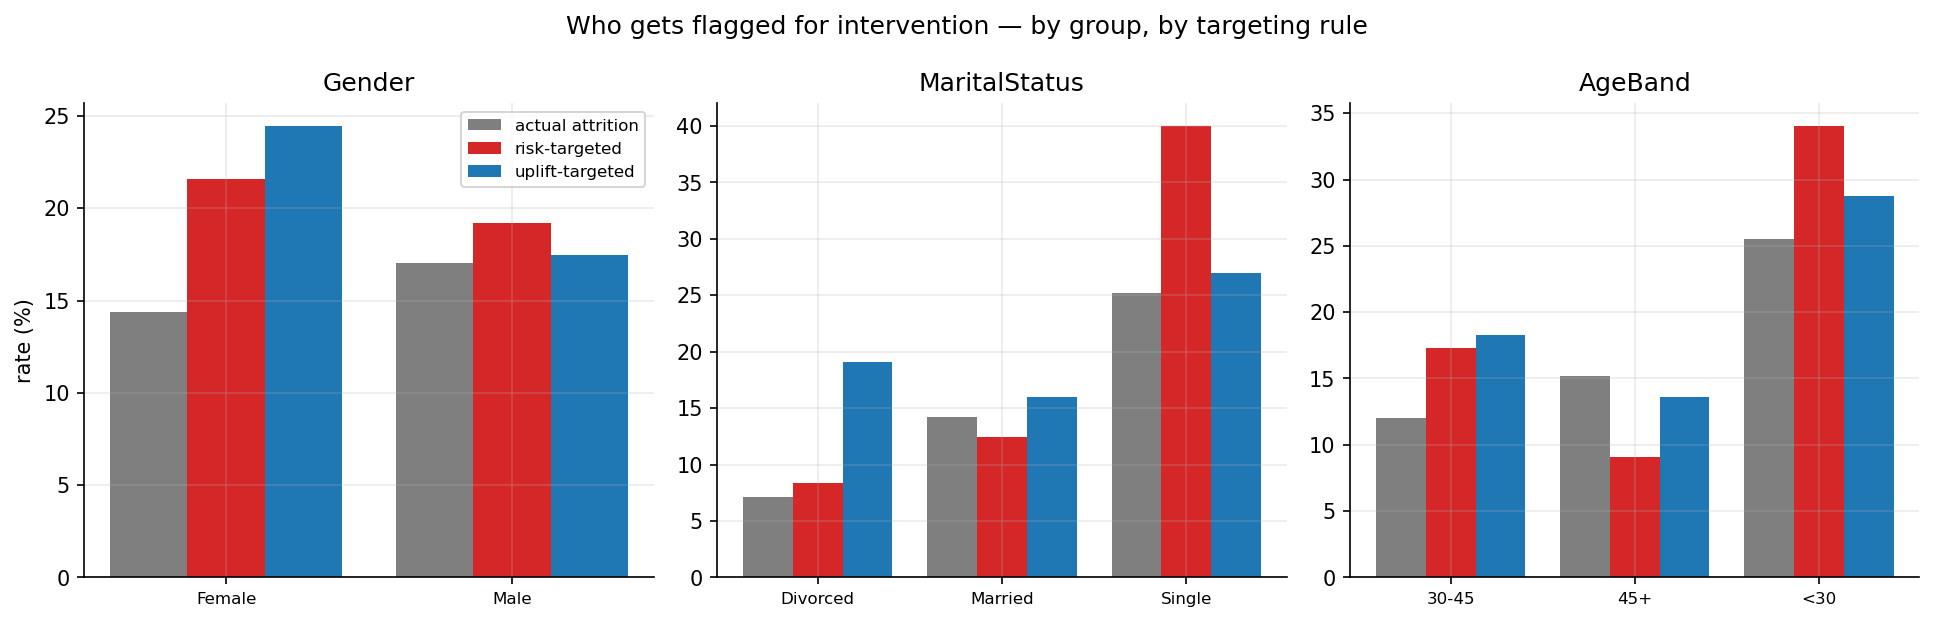

In [2]:
display(pd.read_csv('figures/fairness_metrics.csv').round(3))
Image('figures/fairness_selection_rates.png')

## The efficacy–fairness frontier (Ext C)

A single dial λ interpolates the targeting rule from pure-risk (λ=0) to pure-uplift (λ=1) at a fixed budget. Moving toward uplift is a *Pareto improvement on the worst-affected group* — it averts more attrition **and** lifts the weakest four-fifths ratio (0.21→0.47) — but the gains are attribute-specific (Gender parity erodes) and **no rule clears four-fifths on every attribute**. The endpoints reproduce the audit above.

,lambda,attrition_averted,min_dp_ratio,dp_ratio_Gender,dp_ratio_MaritalStatus,dp_ratio_AgeBand
0,0.00,0.029,0.208,0.890,0.208,0.267
1,0.05,0.030,0.213,0.842,0.213,0.267
2,0.10,0.030,0.218,0.890,0.218,0.267
3,0.15,0.032,0.259,0.842,0.280,0.259
4,0.20,0.034,0.209,0.842,0.318,0.209
5,0.25,0.034,0.251,0.890,0.318,0.251
6,0.30,0.036,0.259,0.890,0.326,0.259
7,0.35,0.037,0.244,0.942,0.326,0.244
8,0.40,0.038,0.285,0.942,0.365,0.285
9,0.45,0.039,0.285,0.946,0.376,0.285


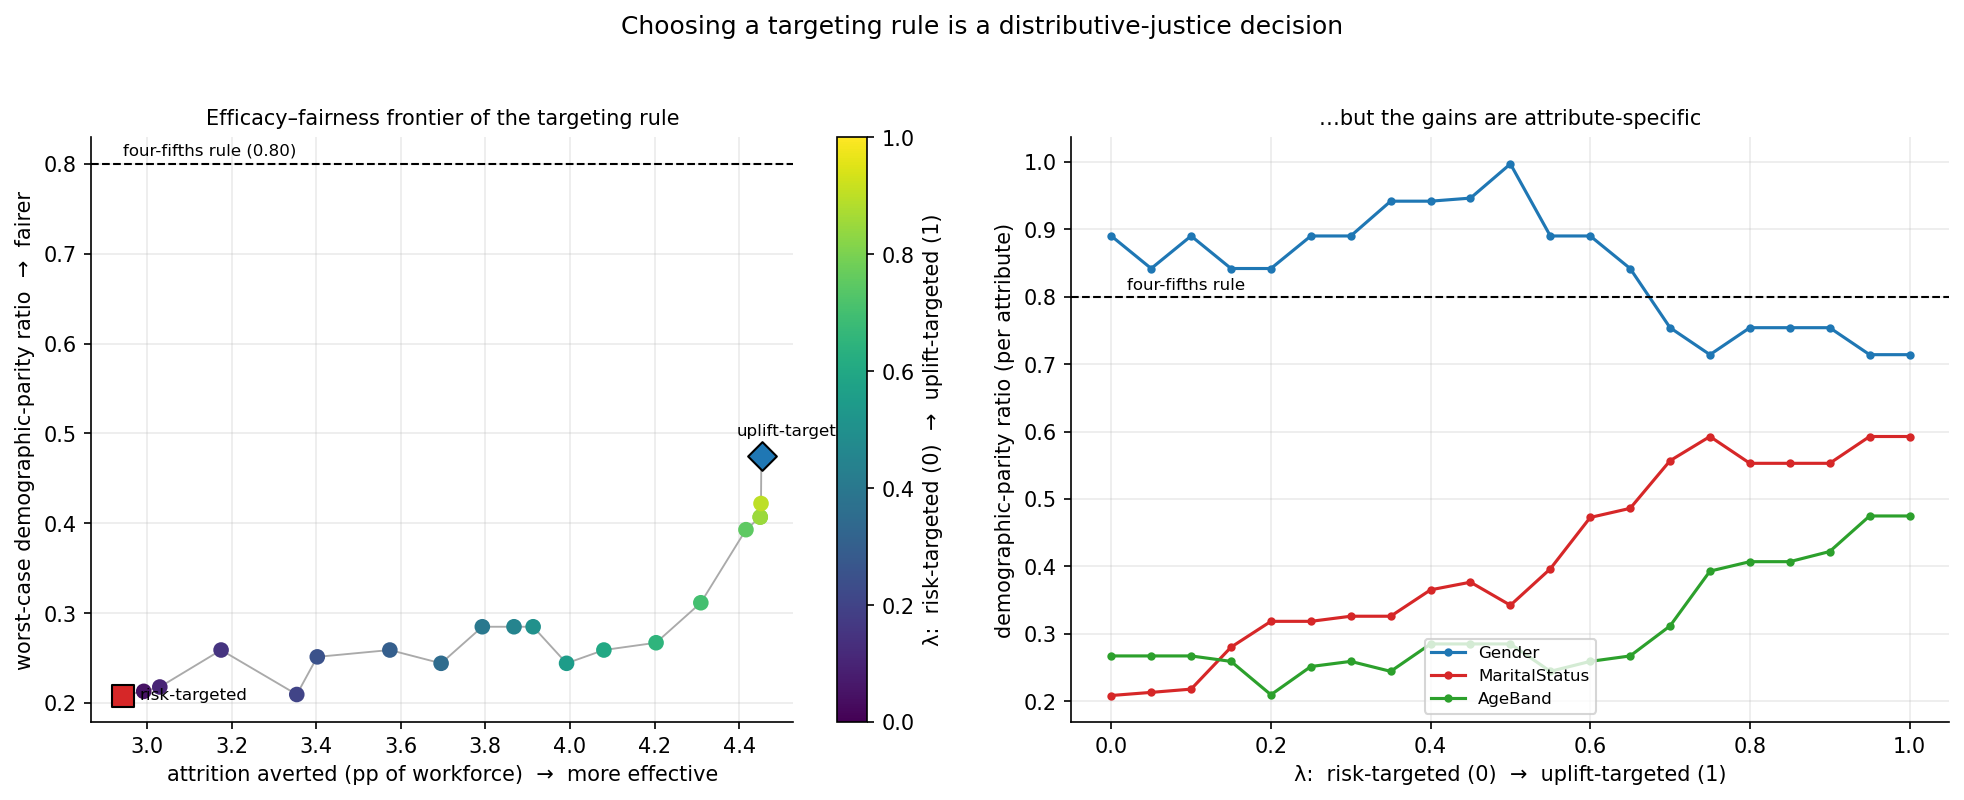

In [3]:
display(pd.read_csv('figures/fairness_frontier.csv').round(3))
Image('figures/fairness_frontier.png')

## Transportability — validated where?

Markets defined by overtime prevalence (ESS confirms each is a real sample, not a few upweighted outliers). The risk *ranking* ports (ROC-AUC holds); the *policy* does not.

,market,overtime_share,ess_share,roc_auc,brier,baseline_rate,averted_uplift
0,original,0.253,1.000,0.814,0.098,0.160,0.044
1,long-hours,0.550,0.681,0.841,0.125,0.242,0.058
2,normalized-hours,0.080,0.864,0.761,0.083,0.113,0.016


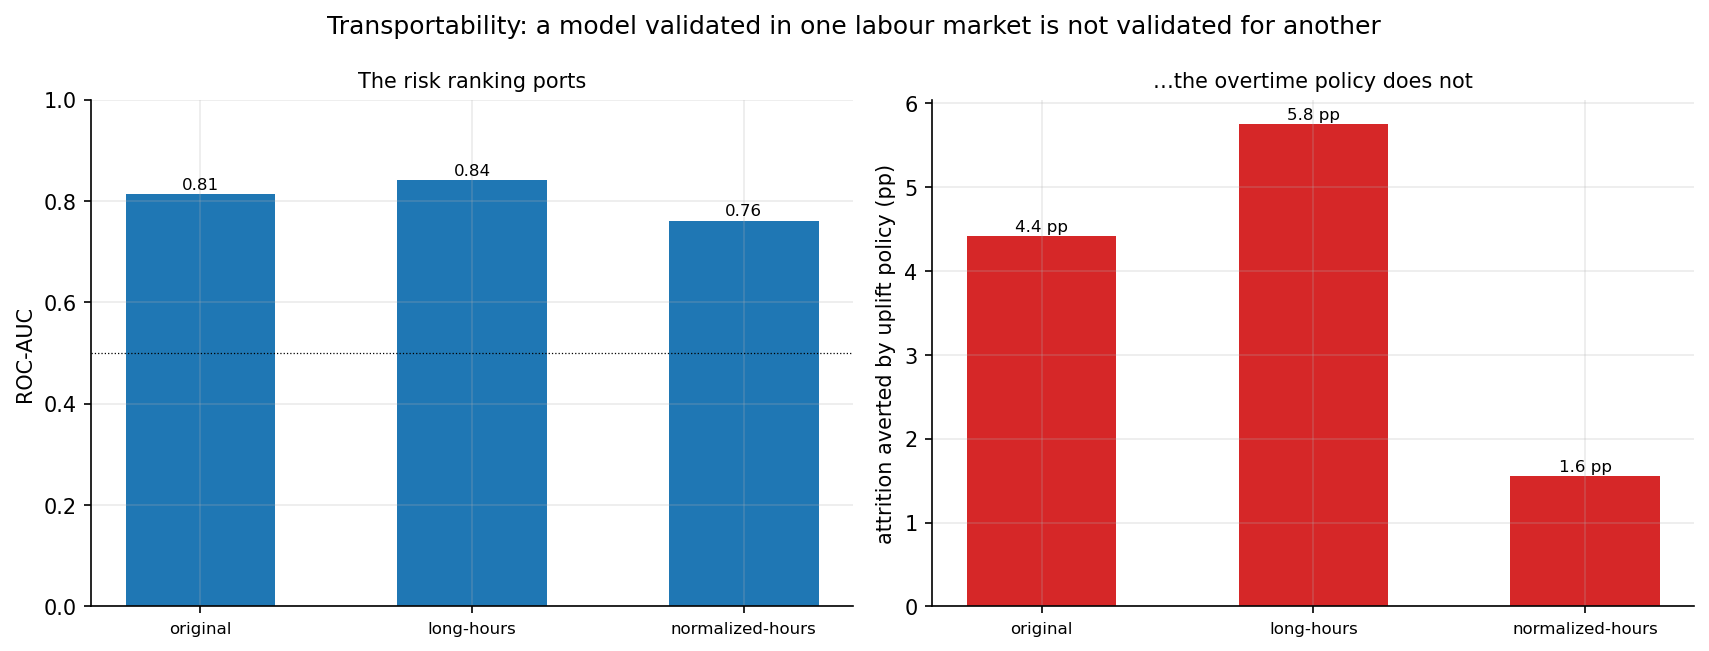

In [4]:
cols = ['market', 'overtime_share', 'ess_share', 'roc_auc', 'brier',
        'baseline_rate', 'averted_uplift']
display(pd.read_csv('figures/transportability.csv')[cols].round(3))
Image('figures/transportability.png')

**Takeaway.** Choosing a targeting rule is a distributive-justice decision, not a neutral default; and a model validated in one labour market is not thereby validated for another. See `model_card.md` and `FRAMING.md` §5–6.